# AzuaHousing.Example

This notebook demonstrates the project and runs:

- Dataset download (Kaggle Melbourne Housing Snapshot)
- Data loading + light feature engineering
- Cross-validation model comparison
- Visual comparison plots (RMSE/R²)
- Fit best model on full training set, evaluate on held-out test set
- Save artifacts to `artifacts/`
- Run inference and compute evaluation metrics on a held-out split
- Inspect prediction errors and visualize results
- Interactive (manual) single-row prediction

**Default dataset path**: `data/melb_data.csv`.


In [1]:
import os, shutil, math, json
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import kagglehub

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from azua_utils import load_csv, train_select_best, save_artifacts, load_model

## Download dataset to `data/`

We download the Kaggle dataset using `kagglehub`, then copy `melb_data.csv` into `./data`.
If the file already exists, we reuse it.


In [2]:
os.makedirs("data", exist_ok=True)
dst = Path("data") / "melb_data.csv"

if not dst.exists():
    cache_dir = Path(kagglehub.dataset_download("dansbecker/melbourne-housing-snapshot"))
    print("cache_dir:", cache_dir)
    src = next(cache_dir.rglob("melb_data.csv"))
    shutil.copyfile(src, dst)
    print("saved:", dst, "| size:", dst.stat().st_size)
else:
    print("found existing:", dst, "| size:", dst.stat().st_size)

found existing: data/melb_data.csv | size: 2091239


## Load dataset

The loader drops rows missing `Price` and, if a `Date` column exists, adds `Year` and `Month` features.


In [3]:
DATA_PATH = os.environ.get("DATA_PATH", "data/melb_data.csv")
print("DATA_PATH =", DATA_PATH)

df_raw = load_csv(
    DATA_PATH,
    target="Price",
    date_cols=["Date"],
    derive_date_parts=True,
    drop_cols=["Date"],  # keep pipeline sane; Date string is high-cardinality
)

print("raw shape:", df_raw.shape)
df_raw.head()

DATA_PATH = data/melb_data.csv
raw shape: (13580, 22)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Date_Year,Date_Month
0,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,2.5,3067.0,2.0,...,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,2016.0,3.0
1,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,2.5,3067.0,2.0,...,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,2016.0,4.0
2,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,2.5,3067.0,3.0,...,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,2017.0,4.0
3,Abbotsford,40 Federation La,3,h,850000.0,PI,Biggin,2.5,3067.0,3.0,...,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,2017.0,4.0
4,Abbotsford,55a Park St,4,h,1600000.0,VB,Nelson,2.5,3067.0,3.0,...,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,2016.0,4.0


## Compute stats (raw)

We compute basic dataset health checks (shape, duplicates, missingness) and summarize the target distribution.


,value
rows,1.358000e+04
cols,2.200000e+01
duplicates,8.000000e+00
num_cols,1.500000e+01
cat_cols,7.000000e+00
target_missing,0.000000e+00
target_mean,1.075684e+06
target_std,6.393107e+05
target_min,8.500000e+04
target_max,9.000000e+06


,missing_%
Date_Year,62.164948
Date_Month,62.164948
BuildingArea,47.496318
YearBuilt,39.580265
CouncilArea,10.081001
Car,0.456554


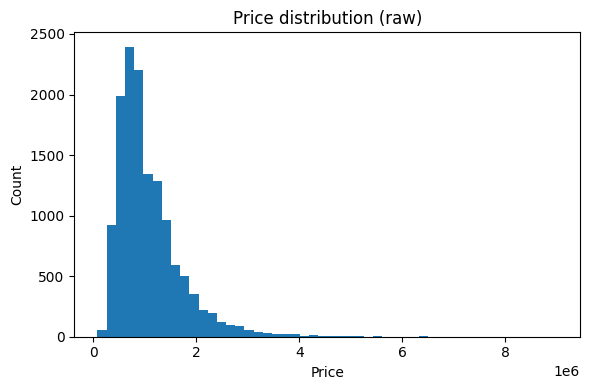

In [4]:
import numpy as np
from IPython.display import display

def compute_basic_stats(df: pd.DataFrame, target: str = "Price", top_missing: int = 12):
    stats = {
        "rows": int(df.shape[0]),
        "cols": int(df.shape[1]),
        "duplicates": int(df.duplicated().sum()),
        "num_cols": int(df.select_dtypes(include=[np.number]).shape[1]),
        "cat_cols": int(df.select_dtypes(exclude=[np.number]).shape[1]),
    }
    if target in df.columns:
        stats["target_missing"] = int(df[target].isna().sum())
        stats["target_mean"] = float(df[target].mean())
        stats["target_std"] = float(df[target].std())
        stats["target_min"] = float(df[target].min())
        stats["target_max"] = float(df[target].max())
    missing = df.isna().mean().sort_values(ascending=False) * 100.0
    missing_tbl = missing[missing > 0].head(top_missing).to_frame("missing_%")
    return pd.Series(stats), missing_tbl

raw_stats, raw_missing = compute_basic_stats(df_raw, target="Price")
display(raw_stats.to_frame("value"))
display(raw_missing)

plt.figure(figsize=(6, 4))
plt.hist(df_raw["Price"].dropna().astype(float), bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price distribution (raw)")
plt.tight_layout()
plt.show()

## Clean data

We apply conservative cleaning:
- Drop exact duplicate rows.
- Coerce selected numeric columns to numeric (invalid values become NaN).
- Replace negative values in fields that must be non-negative with NaN.
- Apply sanity bounds to `YearBuilt` (invalid values become NaN).

We keep rows whenever possible (imputers in the pipeline handle remaining missing values).


In [5]:
def clean_melbourne_df(df: pd.DataFrame) -> pd.DataFrame:
    df2 = df.copy()
    df2 = df2.drop_duplicates()

    coerce_cols = [
        "Postcode", "Propertycount", "YearBuilt", "Car", "Bathroom", "Bedroom2", "Rooms",
        "Distance", "Landsize", "BuildingArea", "Date_Year", "Date_Month"
    ]
    for col in coerce_cols:
        if col in df2.columns:
            df2[col] = pd.to_numeric(df2[col], errors="coerce")

    nonneg_cols = ["Distance", "Landsize", "BuildingArea", "Car", "Bathroom", "Bedroom2", "Rooms"]
    for col in nonneg_cols:
        if col in df2.columns:
            df2.loc[df2[col] < 0, col] = np.nan

    if "YearBuilt" in df2.columns:
        year_now = pd.Timestamp.today().year
        df2.loc[(df2["YearBuilt"] < 1800) | (df2["YearBuilt"] > year_now + 1), "YearBuilt"] = np.nan

    if "Price" in df2.columns:
        df2 = df2.dropna(subset=["Price"])
    return df2


df = clean_melbourne_df(df_raw)
print("clean shape:", df.shape)
df.head()

clean shape: (13572, 22)


,Suburb,Address,Rooms,Type,Price,Method,SellerG,Distance,Postcode,Bedroom2,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Date_Year,Date_Month
0,Abbotsford,85 Turner St,2.0,h,1480000.0,S,Biggin,2.5,3067.0,2.0,...,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0,2016.0,3.0
1,Abbotsford,25 Bloomburg St,2.0,h,1035000.0,S,Biggin,2.5,3067.0,2.0,...,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0,2016.0,4.0
2,Abbotsford,5 Charles St,3.0,h,1465000.0,SP,Biggin,2.5,3067.0,3.0,...,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0,2017.0,4.0
3,Abbotsford,40 Federation La,3.0,h,850000.0,PI,Biggin,2.5,3067.0,3.0,...,94.0,NaN,NaN,Yarra,-37.7969,144.9969,Northern Metropolitan,4019.0,2017.0,4.0
4,Abbotsford,55a Park St,4.0,h,1600000.0,VB,Nelson,2.5,3067.0,3.0,...,120.0,142.0,2014.0,Yarra,-37.8072,144.9941,Northern Metropolitan,4019.0,2016.0,4.0


## Compute stats (cleaned)

We recompute the same statistics after cleaning to verify changes.


,value
rows,1.357200e+04
cols,2.200000e+01
duplicates,0.000000e+00
num_cols,1.500000e+01
cat_cols,7.000000e+00
target_missing,0.000000e+00
target_mean,1.075684e+06
target_std,6.394321e+05
target_min,8.500000e+04
target_max,9.000000e+06


,missing_%
Date_Year,62.142647
Date_Month,62.142647
BuildingArea,47.502210
YearBuilt,39.588859
CouncilArea,10.086944
Car,0.456823


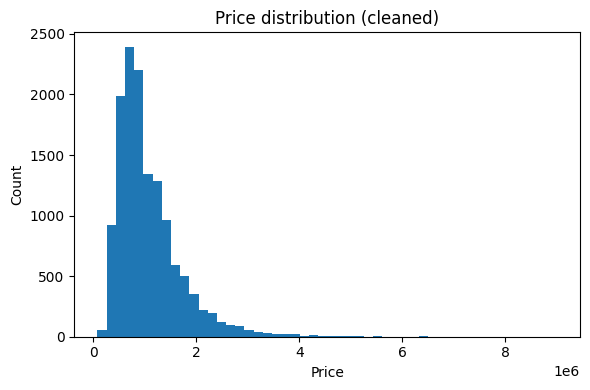

In [6]:
clean_stats, clean_missing = compute_basic_stats(df, target="Price")
display(clean_stats.to_frame("value"))
display(clean_missing)

plt.figure(figsize=(6, 4))
plt.hist(df["Price"].dropna().astype(float), bins=50)
plt.xlabel("Price")
plt.ylabel("Count")
plt.title("Price distribution (cleaned)")
plt.tight_layout()
plt.show()

## Train/test split

We keep a held-out test set for final evaluation.


In [7]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("train:", train_df.shape, "test:", test_df.shape)

train: (10857, 22) test: (2715, 22)


## Model comparison

We evaluate multiple regression algorithms via cross-validation and select the best model by lowest CV RMSE.


In [8]:
bundle = train_select_best(
    train_df,
    folds=5,
    progress=True,
    fold_progress=True,
    return_folds=False
)

results = pd.DataFrame(bundle["all_results"]).sort_values("rmse").reset_index(drop=True)
results[["model", "rmse", "rmse_std", "r2", "r2_std"]]

Model selection (CV):   0%|          | 0/4 [00:00<?, ?it/s]

linreg folds:   0%|          | 0/5 [00:00<?, ?it/s]

elastic folds:   0%|          | 0/5 [00:00<?, ?it/s]

rf folds:   0%|          | 0/5 [00:00<?, ?it/s]

xgb folds:   0%|          | 0/5 [00:00<?, ?it/s]

,model,rmse,rmse_std,r2,r2_std
0,xgb,272728.522312,16694.249310,0.815598,0.025416
1,rf,289323.553099,15470.046240,0.792747,0.024850
2,elastic,470604.857733,215514.078941,0.342228,0.709269
3,linreg,503462.716816,55380.057709,0.365025,0.165034


## Interpret cross-validation results

This cell summarizes what the CV metrics mean using the actual numbers from the run.


In [9]:
best_row = results.iloc[0].to_dict()
second_row = results.iloc[1].to_dict() if len(results) > 1 else None

print("Best by CV RMSE:")
print(f"  model={best_row['model']} | rmse={best_row['rmse']:.2f} ± {best_row.get('rmse_std', 0.0):.2f} | r2={best_row['r2']:.4f} ± {best_row.get('r2_std', 0.0):.4f}")

if second_row is not None:
    print("Runner-up:")
    print(f"  model={second_row['model']} | rmse={second_row['rmse']:.2f} ± {second_row.get('rmse_std', 0.0):.2f} | r2={second_row['r2']:.4f} ± {second_row.get('r2_std', 0.0):.4f}")

print("\nHow to read these metrics:")
print("  - RMSE is in the same units as Price; lower is better.")
print("  - R² measures explained variance; higher is better (1.0 is perfect, 0.0 is baseline mean predictor).")
print("  - Std values reflect variability across folds; smaller std suggests more stable performance.")

Best by CV RMSE:
  model=xgb | rmse=272728.52 ± 16694.25 | r2=0.8156 ± 0.0254
Runner-up:
  model=rf | rmse=289323.55 ± 15470.05 | r2=0.7927 ± 0.0248

How to read these metrics:
  - RMSE is in the same units as Price; lower is better.
  - R² measures explained variance; higher is better (1.0 is perfect, 0.0 is baseline mean predictor).
  - Std values reflect variability across folds; smaller std suggests more stable performance.


## Comparison plots

We generate plots and save them under `artifacts/`.


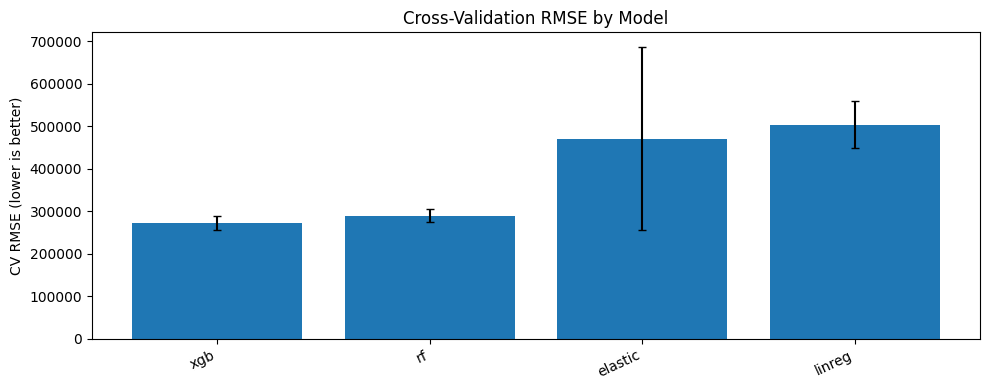

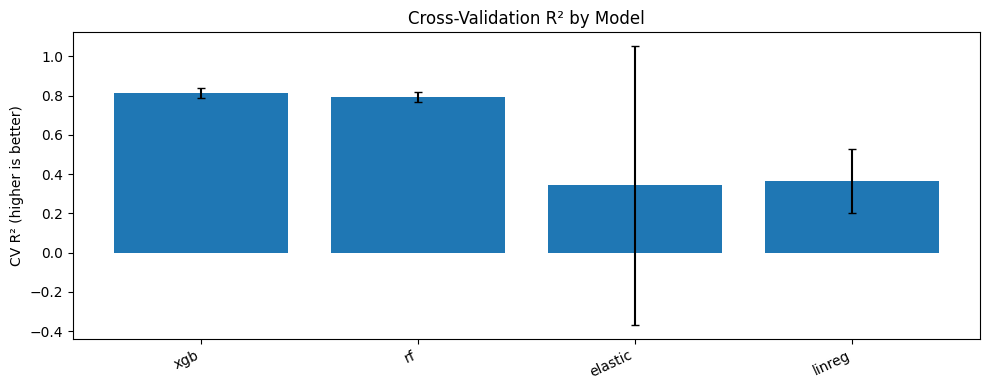

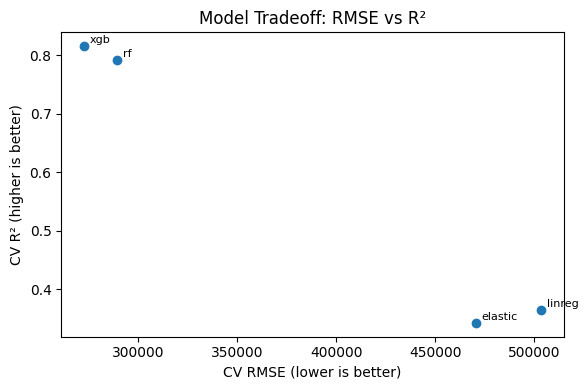

In [10]:
out_dir = Path("artifacts")
out_dir.mkdir(exist_ok=True)

rmse_std = results["rmse_std"] if "rmse_std" in results.columns else None
r2_std = results["r2_std"] if "r2_std" in results.columns else None

plt.figure(figsize=(10, 4))
plt.bar(results["model"], results["rmse"], yerr=rmse_std, capsize=3)
plt.xticks(rotation=25, ha="right")
plt.ylabel("CV RMSE (lower is better)")
plt.title("Cross-Validation RMSE by Model")
plt.tight_layout()
plt.savefig(out_dir / "cv_rmse_by_model.png", dpi=150)
plt.show()

plt.figure(figsize=(10, 4))
plt.bar(results["model"], results["r2"], yerr=r2_std, capsize=3)
plt.xticks(rotation=25, ha="right")
plt.ylabel("CV R² (higher is better)")
plt.title("Cross-Validation R² by Model")
plt.tight_layout()
plt.savefig(out_dir / "cv_r2_by_model.png", dpi=150)
plt.show()

plt.figure(figsize=(6, 4))
plt.scatter(results["rmse"], results["r2"])
for _, row in results.iterrows():
    plt.annotate(row["model"], (row["rmse"], row["r2"]), fontsize=8, xytext=(4, 2), textcoords="offset points")
plt.xlabel("CV RMSE (lower is better)")
plt.ylabel("CV R² (higher is better)")
plt.title("Model Tradeoff: RMSE vs R²")
plt.tight_layout()
plt.savefig(out_dir / "cv_rmse_vs_r2.png", dpi=150)
plt.show()

## Evaluate best pipeline on held-out test set

We evaluate the selected best pipeline on the held-out test split.


In [11]:
best_pipe = bundle["best"]["pipeline"]

X_test = test_df.drop(columns=["Price"], errors="ignore")
y_test = test_df["Price"].astype(float)

pred = best_pipe.predict(X_test)
rmse = math.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Best model:", bundle["best"]["name"])
print("CV RMSE:", round(bundle["best"]["rmse"], 2), "CV R2:", round(bundle["best"]["r2"], 4))
print("TEST RMSE:", round(rmse, 2), "TEST R2:", round(r2, 4))

Best model: xgb
CV RMSE: 272728.52 CV R2: 0.8156
TEST RMSE: 248633.51 TEST R2: 0.8533


## Save artifacts

This writes:

- `artifacts/model.joblib`
- `artifacts/metrics.json`
- `artifacts/cv_results.csv`
- plots: `cv_rmse_by_model.png`, `cv_r2_by_model.png`, `cv_rmse_vs_r2.png`


In [12]:
save_artifacts(bundle, outdir="artifacts")
print("Wrote artifacts/model.joblib and artifacts/metrics.json")

sorted([p.name for p in Path("artifacts").glob("*")])

Wrote artifacts/model.joblib and artifacts/metrics.json


['cv_r2_by_model.png',
 'cv_results.csv',
 'cv_rmse_by_model.png',
 'cv_rmse_vs_r2.png',
 'metrics.json',
 'model.joblib',
 'predictions_sample.csv']

# Usage: Load saved artifacts and run inference


## Verify artifacts exist

Artifacts are created earlier in this notebook under `artifacts/`.
If this cell fails, rerun the training + save cells above.


In [13]:
art_dir = Path("artifacts")
model_path = art_dir / "model.joblib"
meta_path = art_dir / "metrics.json"

print("model_path:", model_path, "exists:", model_path.exists())
print("meta_path :", meta_path, "exists:", meta_path.exists())

if not model_path.exists() or not meta_path.exists():
    raise FileNotFoundError(
        "Missing artifacts. Rerun the cells above that train the model and call save_artifacts()."
    )

model_path: artifacts/model.joblib exists: True
meta_path : artifacts/metrics.json exists: True


## Load model + metadata

We load:
- the fitted sklearn `Pipeline` from `model.joblib`
- training metadata (best model name and CV scores) from `metrics.json`


In [14]:
model = load_model(str(model_path))
with open(meta_path, "r") as f:
    meta = json.load(f)

print("Saved model:", meta.get("model"))
print("Saved CV RMSE:", meta.get("rmse_cv"))
print("Saved CV R2:", meta.get("r2_cv"))
meta

Saved model: xgb
Saved CV RMSE: 272728.5223121026
Saved CV R2: 0.8155984927528046


{'model': 'xgb',
 'rmse_cv': 272728.5223121026,
 'r2_cv': 0.8155984927528046,
 'num_cols': ['Rooms',
  'Distance',
  'Postcode',
  'Bedroom2',
  'Bathroom',
  'Car',
  'Landsize',
  'BuildingArea',
  'YearBuilt',
  'Lattitude',
  'Longtitude',
  'Propertycount',
  'Date_Year',
  'Date_Month'],
 'cat_cols': ['Suburb',
  'Address',
  'Type',
  'Method',
  'SellerG',
  'CouncilArea',
  'Regionname'],
 'drop_cols': [],
 'folds': 5,
 'random_state': 42,
 'target': 'Price'}

## Inference + evaluation

We create a held-out split and evaluate the loaded model on the test set.


In [15]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
print("train:", train_df.shape, "test:", test_df.shape)

X_test = test_df.drop(columns=["Price"], errors="ignore")
y_test = test_df["Price"].astype(float)

pred = model.predict(X_test)

rmse = math.sqrt(mean_squared_error(y_test, pred))
mae = mean_absolute_error(y_test, pred)
r2 = r2_score(y_test, pred)

print("Loaded model name (from metrics.json):", meta.get("model"))
print("TEST RMSE:", round(rmse, 2))
print("TEST MAE :", round(mae, 2))
print("TEST R2  :", round(r2, 4))

train: (10857, 22) test: (2715, 22)
Loaded model name (from metrics.json): xgb
TEST RMSE: 248633.51
TEST MAE : 148928.2
TEST R2  : 0.8533


## Error analysis (best/worst cases)

We inspect predictions with the smallest and largest absolute errors.


In [16]:
eval_df = test_df.copy()
eval_df["y_true"] = y_test.values
eval_df["y_pred"] = pred
eval_df["abs_error"] = (eval_df["y_true"] - eval_df["y_pred"]).abs()

display(eval_df[["y_true", "y_pred", "abs_error"]].sort_values("abs_error").head(10))
display(eval_df[["y_true", "y_pred", "abs_error"]].sort_values("abs_error", ascending=False).head(10))

,y_true,y_pred,abs_error
10171,880000.0,8.799351e+05,64.93750
1955,1145000.0,1.144922e+06,77.75000
9269,945000.0,9.451478e+05,147.75000
3214,382000.0,3.818217e+05,178.34375
2484,765000.0,7.647963e+05,203.68750
8532,650000.0,6.502279e+05,227.93750
5416,410000.0,4.102310e+05,230.96875
9576,375000.0,3.752883e+05,288.28125
3986,545000.0,5.446497e+05,350.31250
11400,559000.0,5.586448e+05,355.18750


,y_true,y_pred,abs_error
9575,7650000.0,4439372.500,3210627.500
12557,6400000.0,3698572.500,2701427.500
3616,6500000.0,3801295.500,2698704.500
9233,5600000.0,3718019.750,1881980.250
4791,3705000.0,1940822.625,1764177.375
12691,2950000.0,1279884.000,1670116.000
4980,760000.0,2402891.500,1642891.500
2579,3400000.0,2026013.500,1373986.500
533,390000.0,1688139.375,1298139.375
9402,3200000.0,4488460.500,1288460.500


## Visualize results

- Predicted vs actual scatter
- Residual histogram


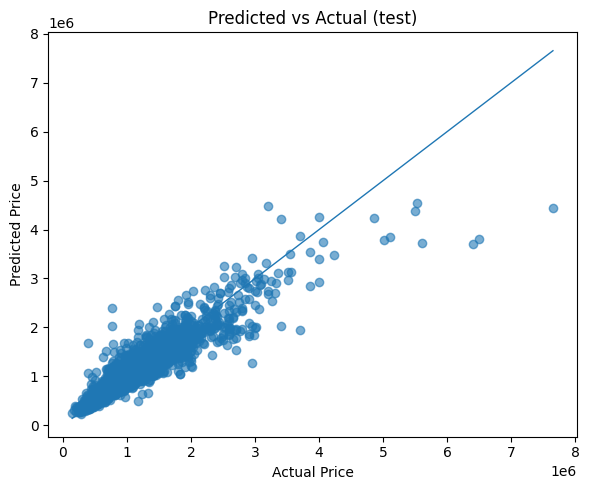

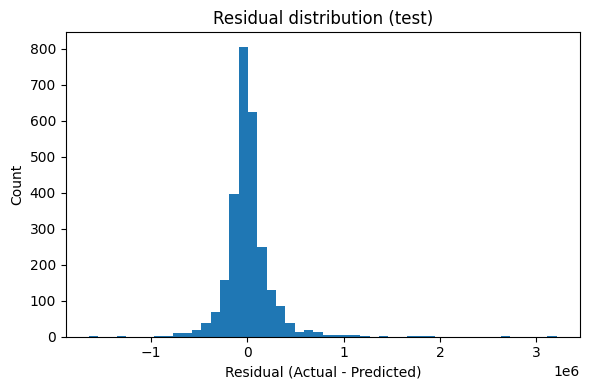

In [17]:
plt.figure(figsize=(6, 5))
plt.scatter(eval_df["y_true"], eval_df["y_pred"], alpha=0.6)
mn = float(min(eval_df["y_true"].min(), eval_df["y_pred"].min()))
mx = float(max(eval_df["y_true"].max(), eval_df["y_pred"].max()))
plt.plot([mn, mx], [mn, mx], linewidth=1)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Predicted vs Actual (test)")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
residuals = (eval_df["y_true"] - eval_df["y_pred"]).astype(float)
plt.hist(residuals, bins=50)
plt.xlabel("Residual (Actual - Predicted)")
plt.ylabel("Count")
plt.title("Residual distribution (test)")
plt.tight_layout()
plt.show()

## Save a prediction sample

We write a small CSV under `artifacts/` for debugging/reporting.


In [18]:
out_path = Path("artifacts") / "predictions_sample.csv"
cols_to_save = ["y_true", "y_pred", "abs_error"]
eval_df[cols_to_save].to_csv(out_path, index=False)
print("Wrote:", out_path, "rows:", len(eval_df))

Wrote: artifacts/predictions_sample.csv rows: 2715


## Single-row prediction example

This shows how to score a single input row (as a dataframe with one row).


In [19]:
one_x = X_test.iloc[[0]].copy()
one_pred = float(model.predict(one_x)[0])
print("Single example predicted price:", one_pred)
one_x

Single example predicted price: 1308972.75


,Suburb,Address,Rooms,Type,Method,SellerG,Distance,Postcode,Bedroom2,Bathroom,...,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount,Date_Year,Date_Month
749,Bentleigh,64 Tucker Rd,3.0,h,S,Buxton,13.0,3204.0,3.0,2.0,...,581.0,170.0,1965.0,Glen Eira,-37.9286,145.0495,Southern Metropolitan,6795.0,NaN,NaN


## Interactive prediction (manual input → prediction)

This section uses **manual input only**: you fill a Python dict, then the notebook converts it into a 1-row DataFrame and predicts.


In [20]:
import numpy as np
import pandas as pd

drop_cols = meta.get("drop_cols", []) if isinstance(meta, dict) else []
feature_cols = [c for c in df.columns if c != "Price" and c not in drop_cols]

num_cols_meta = set(meta.get("num_cols", [])) if isinstance(meta, dict) else set()
cat_cols_meta = set(meta.get("cat_cols", [])) if isinstance(meta, dict) else set()
if not num_cols_meta and not cat_cols_meta:
    num_cols_meta = set(df[feature_cols].select_dtypes(include=[np.number]).columns.tolist())
    cat_cols_meta = set([c for c in feature_cols if c not in num_cols_meta])

print("Drop columns:", drop_cols)
print("Num features :", len(num_cols_meta))
print("Cat features :", len(cat_cols_meta))
print("Total features:", len(feature_cols))

Drop columns: []
Num features : 14
Cat features : 7
Total features: 21


In [21]:
example_input = {
    "Suburb": "Abbotsford",
    "Type": "h",
    "Method": "S",
    "SellerG": "Biggin",
    "CouncilArea": "Yarra",
    "Regionname": "Northern Metropolitan",
    "Rooms": 2,
    "Distance": 2.5,
    "Postcode": 3067,
    "Bedroom2": np.nan,
    "Bathroom": np.nan,
    "Car": np.nan,
    "Landsize": 202,
    "BuildingArea": np.nan,
    "YearBuilt": np.nan,
    "Lattitude": -37.7996,
    "Longtitude": 144.9984,
    "Propertycount": 4019,
    "Date_Year": 2016,
    "Date_Month": 3,
}
